In [7]:
"""
Curtain Plot — Niño3.4 (left) + Hovmöller biomass mean (right)
==============================================================
LEFT  : x = Niño3.4 anomaly (°C),  y = time (1980 top → 2010 bottom)
RIGHT : x = longitude,              y = time (same orientation)
        Colour = biomass mean, equatorial strip 10°S–10°N
"""

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec


In [8]:

# =========================================================
# 1. LOAD BIOMASS DATA
# =========================================================

ds = xr.open_dataset(
    '/Users/dsha0113/Documents/PhD_Work/Data_Analysis/Netcdf_data/skj_4th/skj_totbm_Fref.nc',
    decode_times=False
)

bio_time = pd.date_range('1998-01-15', periods=ds.sizes['time'], freq='MS') \
           + pd.Timedelta(days=14)

ds   = ds.assign_coords(time=bio_time)
data = ds['skj_totbm_Fref']   # (time, lat, lon)

# =========================================================
# 2. LOAD SST — Niño3.4
# =========================================================

era5 = xr.open_dataset(
    "/Users/dsha0113/Documents/PhD_Work/Data_Analysis/Netcdf_data/era5_sst/MonthlymeanSST.nc"
)

sst_full = (
    era5["sst"]
    .sel(valid_time=slice("1998-01-01","2019-12-31"),
         latitude=slice(30,-30),
         longitude=slice(120,290))
    .rename({"valid_time":"time","latitude":"lat","longitude":"lon"})
) - 273.15

nino34_box  = sst_full.sel(lat=slice(5,-5), lon=slice(190,240))
weights     = np.cos(np.deg2rad(nino34_box.lat))
nino34_raw  = nino34_box.weighted(weights).mean(("lat","lon"))
nino34_clim = nino34_raw.groupby("time.month").mean("time")
nino34_anom = nino34_raw.groupby("time.month") - nino34_clim

nino34_smooth = (
    nino34_anom.to_series()
    .rolling(3, center=True, min_periods=1)
    .mean()
)

In [9]:
# =========================================================
# AUTOMATIC ENSO DETECTION
# =========================================================

oni_series = nino34_smooth.copy()

elnino_years = []
lanina_years = []

for yr in sorted(np.unique(oni_series.index.year))[:-1]:

    try:
        dec_value = oni_series.loc[f"{yr}-12-15"]

    except KeyError:

        try:
            dec_value = oni_series.loc[f"{yr}-12-01"]

        except KeyError:
            continue

    if dec_value >= 0.5:
        elnino_years.append(yr)

    elif dec_value <= -0.5:
        lanina_years.append(yr)

print("\nAutomatically detected ENSO years")
print("El Niño:", elnino_years)
print("La Niña:", lanina_years)

# =========================================================
# CONTINUOUS ENSO EVENT PERIODS
# =========================================================

warm_mask = oni_series >= 0.5
cold_mask = oni_series <= -0.5


def get_event_periods(mask):

    periods = []

    start = None

    for t, state in zip(mask.index, mask):

        if state and start is None:
            start = t

        elif (not state) and (start is not None):

            periods.append((start, prev_time))
            start = None

        prev_time = t

    if start is not None:
        periods.append((start, mask.index[-1]))

    return periods


elnino_periods = get_event_periods(warm_mask)
lanina_periods = get_event_periods(cold_mask)

print("\nEl Niño periods:")
for s, e in elnino_periods:
    print(s.strftime('%Y-%m'), 'to', e.strftime('%Y-%m'))

print("\nLa Niña periods:")
for s, e in lanina_periods:
    print(s.strftime('%Y-%m'), 'to', e.strftime('%Y-%m'))

# Equatorial SST mean (10°S–10°N) for 29°C contour on Hovmöller
sst_eq = (
    sst_full.sel(lat=slice(10, -10), lon=slice(120, 290))
    .mean("lat")
    .rolling(time=3, center=True, min_periods=1)
    .mean()
)
sst_lons = sst_eq.lon.values.astype(float)
sst_mat  = sst_eq.values.astype(float)         # (n_time, n_lon)


Automatically detected ENSO years
El Niño: [np.int32(2002), np.int32(2004), np.int32(2006), np.int32(2009), np.int32(2014), np.int32(2015), np.int32(2018)]
La Niña: [np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2005), np.int32(2007), np.int32(2008), np.int32(2010), np.int32(2011), np.int32(2017)]

El Niño periods:
1998-01 to 1998-04
2002-06 to 2003-02
2004-08 to 2005-01
2006-09 to 2007-01
2009-07 to 2010-03
2012-08 to 2012-09
2014-10 to 2016-04
2018-10 to 2019-06
2019-11 to 2019-12

La Niña periods:
1998-06 to 2000-07
2000-10 to 2001-01
2005-12 to 2006-03
2007-08 to 2008-05
2008-11 to 2009-02
2010-06 to 2011-04
2011-08 to 2012-03
2017-10 to 2018-03


In [10]:
# =========================================================
# 3. HOVMÖLLER DATA — equatorial biomass (10°S–10°N)
# =========================================================

bio_eq = (
    data.sel(lat=slice(10, -10), lon=slice(120, 290))
    .mean("lat")
    .rolling(time=3, center=True, min_periods=1)
    .mean()
)

# Anomaly: subtract time-mean at each longitude
bio_mean = bio_eq.mean("time")
bio_eq   = bio_eq - bio_mean

# Pull out plain numpy arrays — avoid any datetime conversion issues
lons    = bio_eq.lon.values.astype(float)          # (n_lon,)
bio_mat = bio_eq.values.astype(float)              # (n_time, n_lon)

# Build a plain float year array for the y-axis (avoids mdates entirely)
n_time  = bio_mat.shape[0]
# fractional year: 1980.04, 1980.12, … 2010.96
year_arr = np.array([t.year + (t.month - 0.5) / 12 for t in bio_time])

# Nino34 on same fractional-year axis
nino_year_arr = np.array([t.year + (t.month - 0.5) / 12
                           for t in nino34_smooth.index])
nino_vals     = nino34_smooth.values


In [11]:
# =========================================================
# 4. ENSO YEARS
# =========================================================

EL_NINO_COL = '#E8523A'
LA_NINA_COL = '#4A90D9'
OCEAN_DARK  = '#0A1628'
OCEAN_MID   = '#0D1E3A'
GRID_COLOR  = '#1E3A5F'
TEXT_LIGHT  = "#1989C5"
TEXT_DIM    = "#253D4F"

bio_mat shape: (264, 681)
LON2 shape:    (264, 681)
YR2 shape:     (264, 681)
bio_mat min/max: -0.2201 / 0.9144


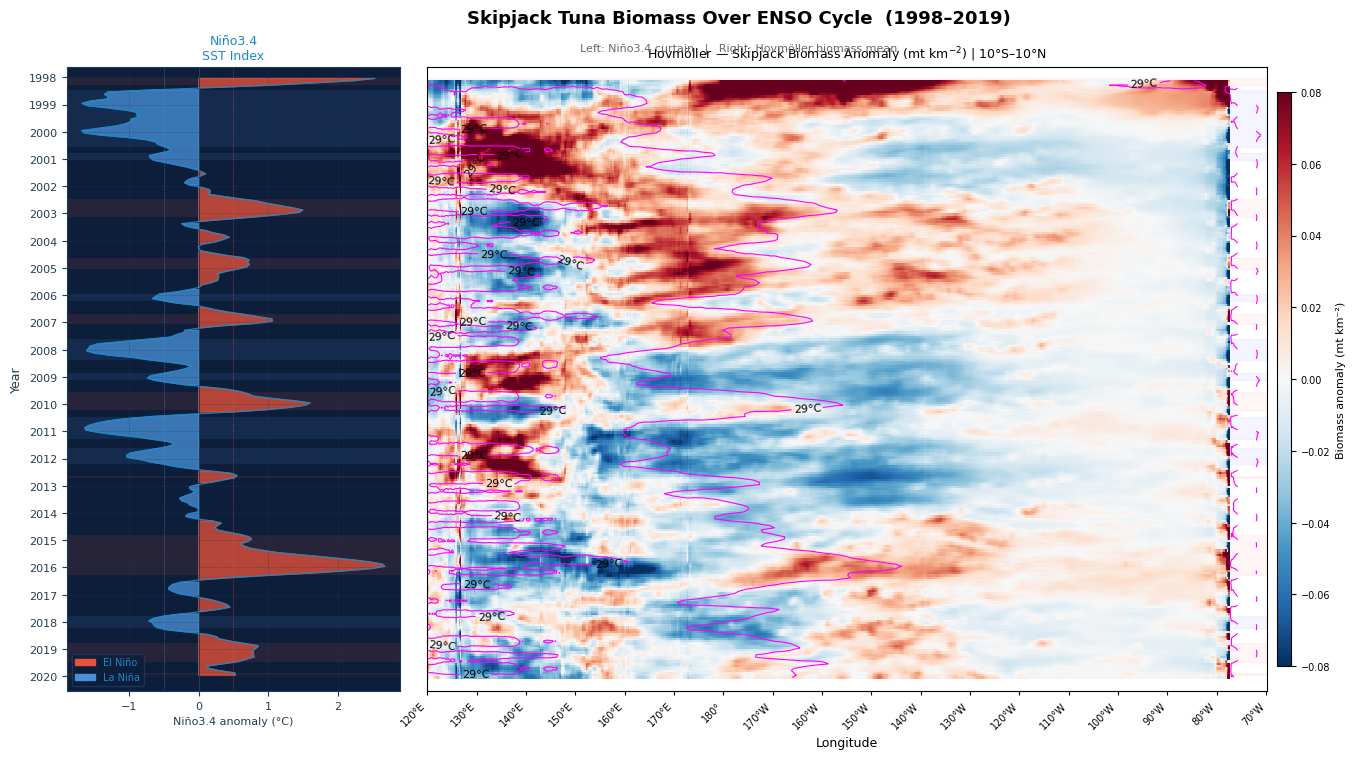

In [12]:
# =========================================================
# 5. FIGURE
# =========================================================

plt.rcParams.update({'font.family':'sans-serif','font.sans-serif':['DejaVu Sans']})

fig = plt.figure(figsize=(16, 8), facecolor='white')

gs = GridSpec(1, 2, figure=fig,
              left=0.08, right=0.93,
              top=0.88,  bottom=0.10,
              wspace=0.04,
              width_ratios=[1, 3])

ax_nino = fig.add_subplot(gs[0, 0])
ax_hov  = fig.add_subplot(gs[0, 1])

# =========================================================
# LEFT: Niño3.4 curtain
# =========================================================

ax_nino.set_facecolor(OCEAN_MID)
for sp in ax_nino.spines.values():
    sp.set_edgecolor(GRID_COLOR)
ax_nino.tick_params(colors=TEXT_DIM, labelsize=8)
ax_nino.grid(color=GRID_COLOR, linewidth=0.4, linestyle='--', alpha=0.6)

ax_nino.fill_betweenx(nino_year_arr, nino_vals, 0,
                       where=(nino_vals >= 0),
                       color=EL_NINO_COL, alpha=0.75)
ax_nino.fill_betweenx(nino_year_arr, nino_vals, 0,
                       where=(nino_vals < 0),
                       color=LA_NINA_COL, alpha=0.75)
ax_nino.plot(nino_vals, nino_year_arr, color=TEXT_LIGHT, linewidth=0.8, zorder=4)
ax_nino.axvline(0,    color=TEXT_DIM, linewidth=0.7)
ax_nino.axvline( 0.5, color=EL_NINO_COL, linewidth=0.5, linestyle=':')
ax_nino.axvline(-0.5, color=LA_NINA_COL, linewidth=0.5, linestyle=':')

# =========================================================
# ENSO EVENT SHADING
# =========================================================

for start, end in elnino_periods:

    y0 = start.year + (start.month - 0.5) / 12
    y1 = end.year + (end.month - 0.5) / 12

    ax_nino.axhspan(
        y0,
        y1,
        color=EL_NINO_COL,
        alpha=0.12,
        linewidth=0
    )

for start, end in lanina_periods:

    y0 = start.year + (start.month - 0.5) / 12
    y1 = end.year + (end.month - 0.5) / 12

    ax_nino.axhspan(
        y0,
        y1,
        color=LA_NINA_COL,
        alpha=0.12,
        linewidth=0
    )

ax_nino.set_ylim(year_arr[-1] + 0.5, year_arr[0] - 0.5)   # 1980 at top
ax_nino.yaxis.set_major_locator(mticker.MultipleLocator(1))
ax_nino.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
ax_nino.xaxis.set_major_locator(mticker.MultipleLocator(1))

ax_nino.set_xlabel('Niño3.4 anomaly (°C)', color=TEXT_DIM, fontsize=8)
ax_nino.set_ylabel('Year', color=TEXT_DIM, fontsize=9)
ax_nino.set_title('Niño3.4\nSST Index', color=TEXT_LIGHT, fontsize=9, pad=6)
ax_nino.xaxis.label.set_color(TEXT_DIM)
ax_nino.yaxis.label.set_color(TEXT_DIM)

ax_nino.legend(
    handles=[mpatches.Patch(color=EL_NINO_COL, label='El Niño'),
             mpatches.Patch(color=LA_NINA_COL, label='La Niña')],
    fontsize=7, loc='lower left',
    facecolor=OCEAN_MID, edgecolor=GRID_COLOR, labelcolor=TEXT_LIGHT
)

# =========================================================
# RIGHT: Hovmöller
# =========================================================

ax_hov.set_facecolor('white')
for sp in ax_hov.spines.values():
    sp.set_edgecolor('black')
    sp.set_linewidth(0.8)
ax_hov.tick_params(colors='black', labelsize=8, direction='out', length=3)
ax_hov.grid(False)

# Build 2-D grids using plain float year and longitude
LON2, YR2 = np.meshgrid(lons, year_arr)

print(f"bio_mat shape: {bio_mat.shape}")
print(f"LON2 shape:    {LON2.shape}")
print(f"YR2 shape:     {YR2.shape}")
print(f"bio_mat min/max: {np.nanmin(bio_mat):.4f} / {np.nanmax(bio_mat):.4f}")

cmap = plt.get_cmap('RdBu_r')
norm = mcolors.TwoSlopeNorm(vmin=-0.08, vcenter=0, vmax=0.08)

pcm = ax_hov.pcolormesh(
    LON2, YR2, bio_mat,
    cmap=cmap, norm=norm,
    shading='auto',
)

ax_hov.set_ylim(year_arr[-1] + 0.5, year_arr[0] - 0.5)   # 1980 at top

# =========================================================
# ENSO EVENT MARKERS
# =========================================================

for start, end in elnino_periods:

    y0 = start.year + (start.month - 0.5) / 12
    y1 = end.year + (end.month - 0.5) / 12

    ax_hov.axhspan(
        y0,
        y1,
        color='red',
        alpha=0.04,
        zorder=0
    )

for start, end in lanina_periods:

    y0 = start.year + (start.month - 0.5) / 12
    y1 = end.year + (end.month - 0.5) / 12

    ax_hov.axhspan(
        y0,
        y1,
        color='blue',
        alpha=0.04,
        zorder=0
    )

# 29°C isotherm contour — use SST time axis aligned to bio year_arr
sst_LON2, sst_YR2 = np.meshgrid(sst_lons, year_arr)
cs = ax_hov.contour(
    sst_LON2, sst_YR2, sst_mat,
    levels=[29],
    colors='magenta',
    linewidths=0.8,
    linestyles='solid',
)

ax_hov.clabel(cs, fmt='%d°C', fontsize=8, inline=True, colors='black')

# y-axis: every year
ax_hov.yaxis.set_visible(False)

# x-axis: longitude labels
lon_ticks = np.arange(120, 300, 10)
ax_hov.set_xticks(lon_ticks)

def lon_label(l):
    if l == 180:   return '180°'
    elif l < 180:  return f'{int(l)}°E'
    else:          return f'{int(360-l)}°W'

ax_hov.set_xticklabels([lon_label(l) for l in lon_ticks],
                        fontsize=7, rotation=45, ha='right', color='black')

ax_hov.set_xlabel('Longitude', color='black', fontsize=9)
ax_hov.set_title(
    r'Hovmöller — Skipjack Biomass Anomaly (mt km$^{-2}$) | 10°S–10°N',
    color='black', fontsize=9, pad=6
)

# Colorbar
cbar = fig.colorbar(pcm, ax=ax_hov,
                    orientation='vertical',
                    shrink=0.92, pad=0.01, aspect=40)
cbar.set_label('Biomass anomaly (mt km⁻²)', color='black', fontsize=8)
cbar.ax.tick_params(colors='black', labelsize=7, direction='out')
cbar.outline.set_edgecolor('black')

# =========================================================
# FIGURE TITLE
# =========================================================

fig.text(0.5, 0.935,
         'Skipjack Tuna Biomass Over ENSO Cycle  (1998–2019)',
         ha='center', color='black', fontsize=13, fontweight='bold')
fig.text(0.5, 0.900,
         'Left: Niño3.4 curtain   |   Right: Hovmöller biomass mean',
         ha='center', color='dimgray', fontsize=8)

plt.show()